<a href="https://colab.research.google.com/github/MichaelMaroko/Data-Science-HW1/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Structural Analysis ===
Dataset Shape: 1503 rows, 12 columns

--- Data Types & Missing Values ---
                 Data Type  Missing Values  Missing %
Transaction_ID       int64               0       0.00
City                object               0       0.00
Property_Type       object               0       0.00
Rooms              float64               0       0.00
Floor                int64               0       0.00
Area_SQM           float64               0       0.00
Price_ILS          float64               0       0.00
Build_Year         float64              50       3.33
Transaction_Date    object               0       0.00
Has_Elevator          bool               0       0.00
Has_Parking           bool               0       0.00
Balcony_SQM        float64              30       2.00

--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
Transaction_ID,1503.0,1.074940e+04,4.334345e+02,10001.0,10373.50,10749.0,11124.5,11500.0
Rooms,1503.0,3.855622e+00,1.618833e+00,2.0,3.00,4.0,4.5,50.0
Floor,1503.0,7.091816e+00,5.229190e+00,0.0,3.00,7.0,11.0,29.0
Area_SQM,1503.0,1.164060e+02,6.572606e+01,0.0,74.25,96.8,122.9,348.4
Price_ILS,1503.0,4.102621e+06,2.994534e+06,-500000.0,2294500.00,3033000.0,4583500.0,21476000.0
Build_Year,1453.0,1.992096e+03,1.896115e+01,1960.0,1975.00,1992.0,2008.0,2025.0
Balcony_SQM,1473.0,1.673734e+01,1.688602e+01,0.0,0.00,13.1,31.4,50.0


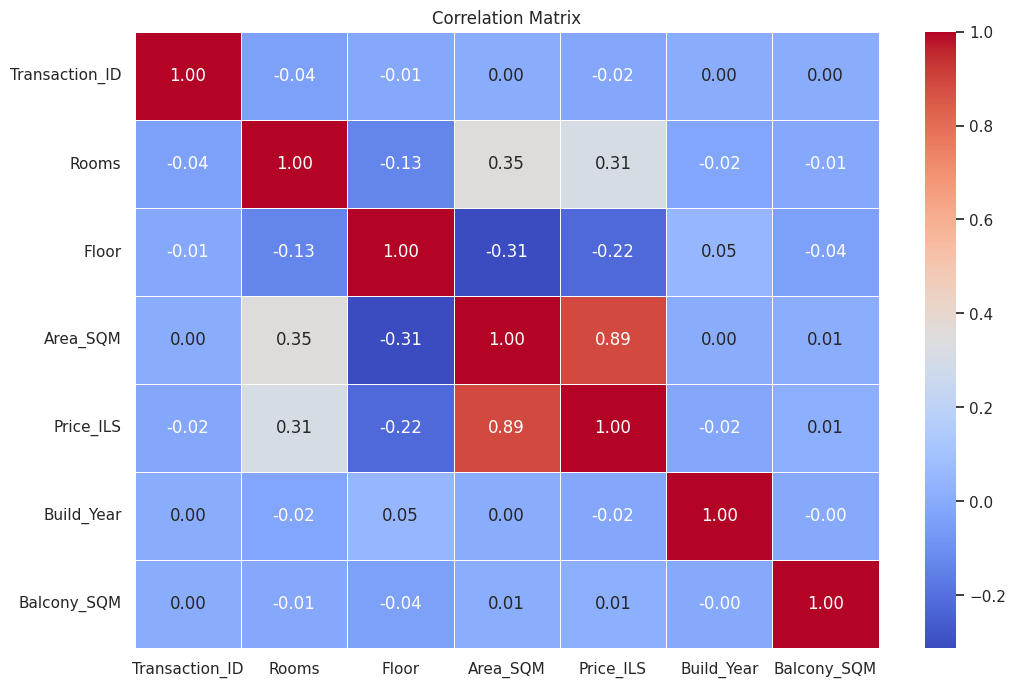

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת סגנון גרפי אחיד
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# טעינת קובץ הנתונים
file_name = "israel_real_estate_dataset.csv"
df = pd.read_csv(file_name)

# 1. Structural Analysis
print("=== Structural Analysis ===")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- Data Types & Missing Values ---")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)
print("\n--- Statistical Summary ---")
display(df.describe().T)

# יצירת מטריצת קורלציות למשתנים מספריים
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### 2.2 Distribution Analysis & Outlier Exploration
* **Skewness & Heavy Tails:** נתוני הנדל"ן (ובעיקר המחיר, השטח ושטח המגרש) מציגים לרוב הטיה חיובית ימנית מובהקת (Positive Skewness) וערכי Kurtosis גבוהים, המעידים על זנב כבד (Heavy Tails) ונוכחות של נכסי יוקרה/עסקאות חריגות.
* **Extreme Values vs. Noise:**
  - חריגים פיזיקליים לגיטימיים: דירות פנטהאוז או וילות רחבות ידיים עם שווי גבוה משמעותית מהממוצע.
  - שגיאות הזנה (Data-entry errors / Artifacts): ערכים כגון מספר חדרים חריג (0 או מעל 15) או מחיר אפס שאינם מייצגים עסקאות שוק אמיתיות.

=== Distribution Shape Metrics (Skewness & Kurtosis) ===


,Feature,Skewness,Kurtosis
0,Transaction_ID,0.003,-1.202
1,Rooms,15.504,438.845
2,Floor,0.671,0.928
3,Area_SQM,1.785,2.638
4,Price_ILS,2.247,5.722
5,Build_Year,0.007,-1.227
6,Balcony_SQM,0.481,-1.211


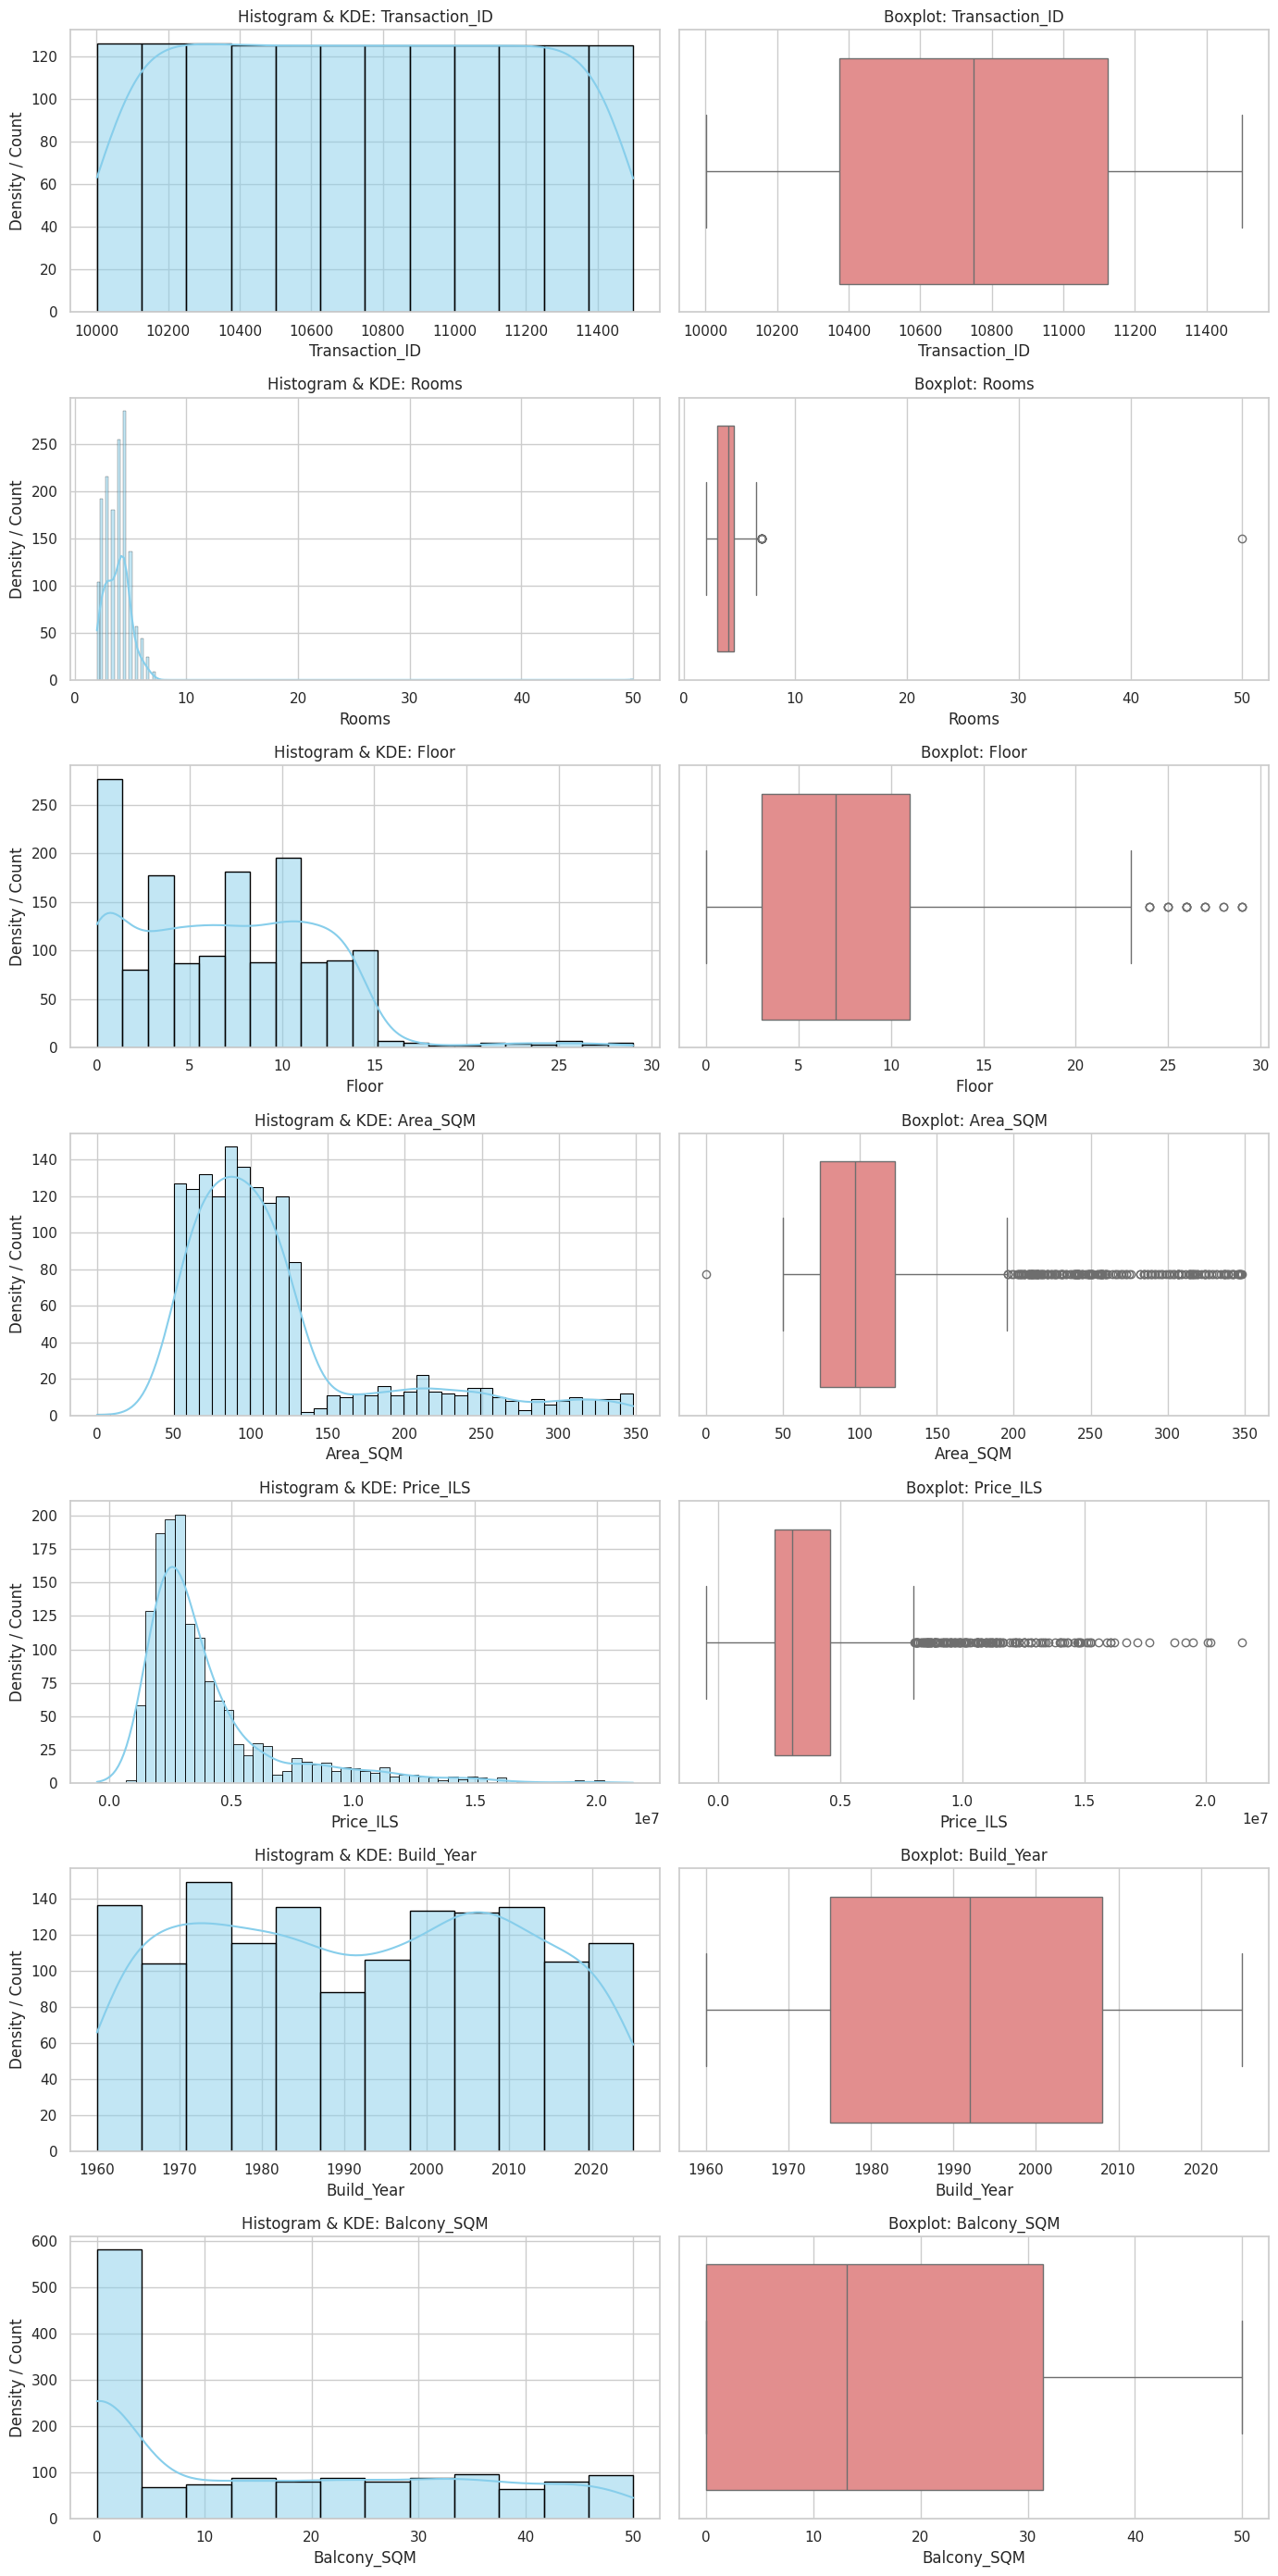

In [2]:
from scipy import stats

# זיהוי עמודות מספריות
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# טבלה לריכוז Skewness ו-Kurtosis
stats_summary = []

for col in numeric_cols:
    val_skew = df[col].skew()
    val_kurt = df[col].kurtosis()
    stats_summary.append({
        'Feature': col,
        'Skewness': round(val_skew, 3),
        'Kurtosis': round(val_kurt, 3)
    })

stats_df = pd.DataFrame(stats_summary)
print("=== Distribution Shape Metrics (Skewness & Kurtosis) ===")
display(stats_df)

# יצירת היסטוגרמות ותרשימי קופסה לכל המשתנים המספריים
n_cols = len(numeric_cols)
fig, axes = plt.subplots(nrows=n_cols, ncols=2, figsize=(14, 4 * n_cols))

for i, col in enumerate(numeric_cols):
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Histogram & KDE: {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density / Count')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot: {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

# חלק 3: הורדת ממד באמצעות ניתוח רכיבים עיקריים (PCA)

## 1. רקע ואינטואיציה מתמטית
ניתוח רכיבים עיקריים (Principal Component Analysis - PCA) היא שיטה לינארית לא-מונחית (Unsupervised) להורדת ממד. מטרת השיטה היא למצוא מערכת צירים אורתוגונלית (בלתי תלויה) חדשה במרחב הנתונים, כך שהציר הראשון (PC1) לוכד את כיוון השונות המקסימלית של הדגימות, הציר השני (PC2) לוכד את מירב השונות הנותרת במאונך לציר הראשון, וכן הלאה.

ברמה המתמטית:
1. **סטנדרטיזציה:** היות ש-PCA מבוסס על שונות ומרחקים אוקלידיים, משתנים בעלי סדרי גודל שונים (כגון מחיר בשקלים לעומת מספר חדרים) עלולים להשתלט על הרכיבים. לכן, חובה לבצע תחילה תקנון (StandardScaler) כך שלכל משתנה יהיה ממוצע 0 וסטיית תקן 1.
2. **מטריצת שונות משותפת (Covariance Matrix):** אנו מחשבים את מטריצת הקו-וריאנס בין כלל המשתנים המנורמלים.
3. **פירוק לערכים עצמיים ווקטורים עצמיים (Eigendecomposition):**
   - הוקטורים העצמיים (Eigenvectors / Loadings) מגדירים את כיווני הרכיבים העיקריים החדשים.
   - הערכים העצמיים (Eigenvalues) מייצגים את גודל השונות הנלכדת על ידי כל רכיב.

## 2. מטרות הניתוח בחלק זה
1. **הסרת יתירות (Redundancy):** בנתוני נדל"ן קיימת קורלציה מובנית גבוהה בין מאפיינים שונים (כגון שטח הדירה, מספר חדרים, שטח מגרש ומחיר). PCA מאפשר לאחד משתנים מתואמים לכדי רכיבים תמציתיים ללא תלות לינארית הדדית.
2. **בחינת שימור המידע (Explained Variance & Scree Plot):** ניתוח שיעור השונות המוסברת המצטבר לצורך בחירת מספר הרכיבים המינימלי שמייצג נאמנה את מבנה הנתונים (למשל שמירה על 70%-80% מסך השונות).
3. **הטלה והצגה ויזואלית (2D & 3D Projections):** הטלת מרחב הנתונים הרב-ממדי למרחב דו-ממדי ותלת-ממדי, ובחינת הפרדת האשכולות ומבנה החריגים במרחב המצומצם.
4. **פרשנות המשקולות (Feature Loadings):** זיהוי המשתנים המקוריים בעלי התרומה הדומיננטית ביותר לכל אחד מהרכיבים הראשיים.

=== Explained Variance Ratio per Component ===
PC1: Individual = 0.3162 (31.62%), Cumulative = 0.3162 (31.62%)
PC2: Individual = 0.1459 (14.59%), Cumulative = 0.4622 (46.22%)
PC3: Individual = 0.1448 (14.48%), Cumulative = 0.6070 (60.70%)
PC4: Individual = 0.1420 (14.20%), Cumulative = 0.7490 (74.90%)
PC5: Individual = 0.1237 (12.37%), Cumulative = 0.8727 (87.27%)
PC6: Individual = 0.1123 (11.23%), Cumulative = 0.9850 (98.50%)
PC7: Individual = 0.0150 (1.50%), Cumulative = 1.0000 (100.00%)


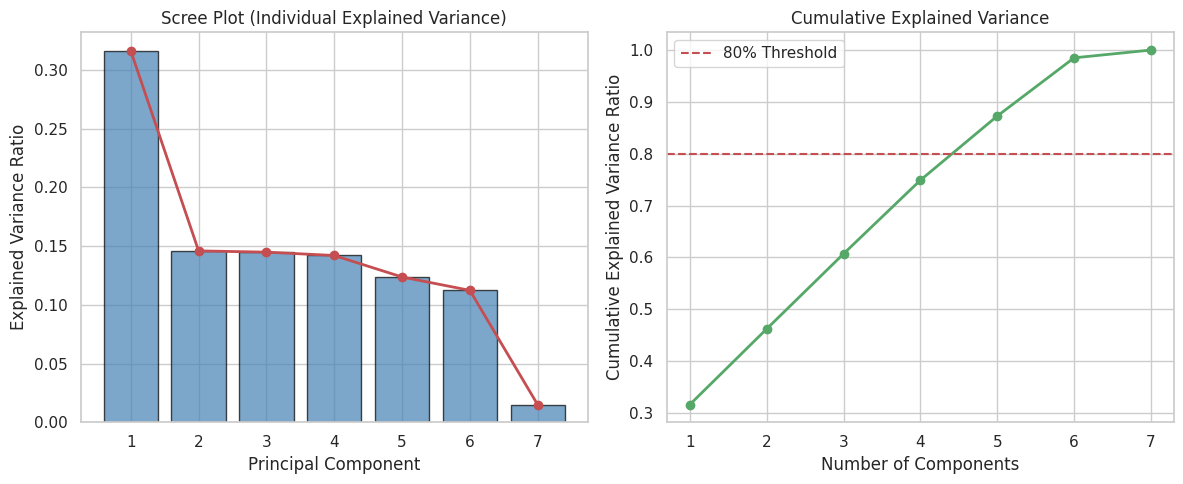

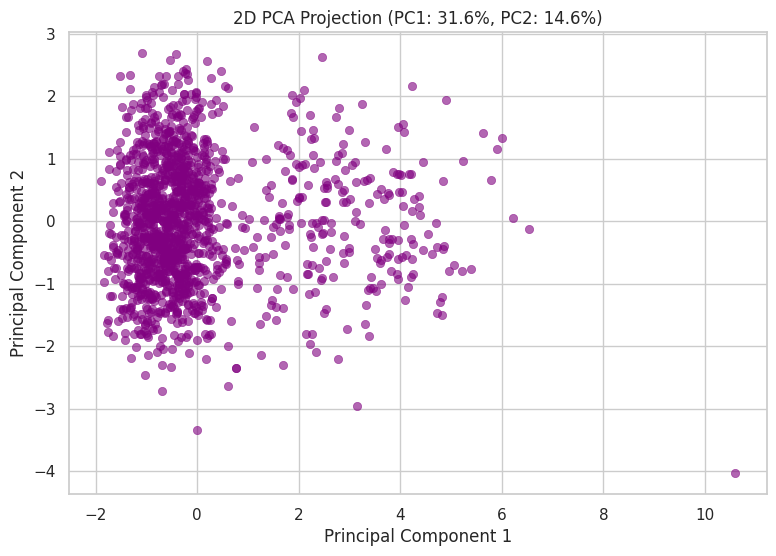

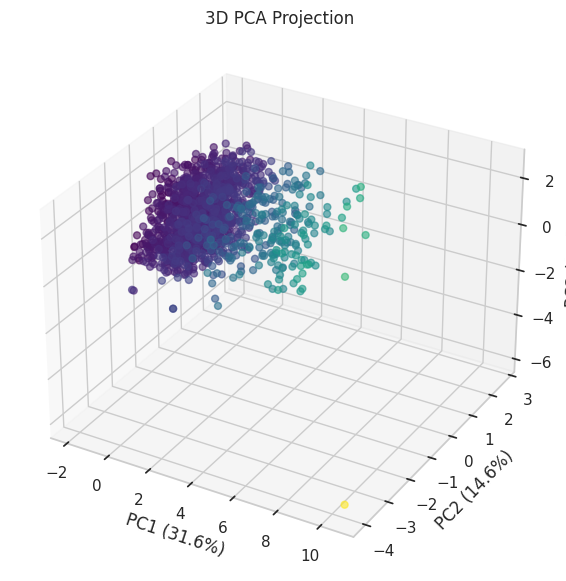

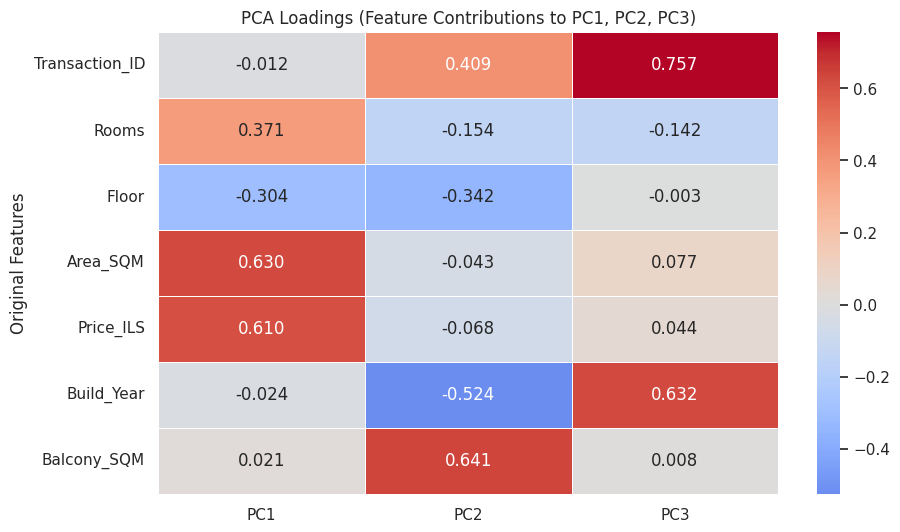

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import mpl_toolkits.mplot3d  # noqa: F401

# 1. הכנת הנתונים: בחירת משתנים מספריים והסרת שורות עם ערכים חסרים במידה וקיימים
numeric_data = df.select_dtypes(include=[np.number]).dropna()

# 2. סטנדרטיזציה (תקנון) חובה לפני PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_data)

# 3. התאמת מודל PCA מלא (לכל הממדים)
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("=== Explained Variance Ratio per Component ===")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i}: Individual = {ev:.4f} ({ev*100:.2f}%), Cumulative = {cv:.4f} ({cv*100:.2f}%)")

# 4. יצירת Scree Plot וגרף שונות מצטברת
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='steelblue', edgecolor='black')
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'ro-', linewidth=2)
plt.title('Scree Plot (Individual Explained Variance)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance) + 1))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'go-', linewidth=2)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()

plt.tight_layout()
plt.show()

# 5. הטלה ל-2D ו-3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])

# תצוגה דו-ממדית (2D Projection)
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.6, color='purple', edgecolor=None)
plt.title(f'2D PCA Projection (PC1: {explained_variance[0]*100:.1f}%, PC2: {explained_variance[1]*100:.1f}%)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# תצוגה תלת-ממדית (3D Projection)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['PC1'], cmap='viridis', alpha=0.6, s=25)
ax.set_title('3D PCA Projection')
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]*100:.1f}%)')
plt.show()

# 6. מטריצת משקולות (Loadings / Heatmap) להבנת משמעות הרכיבים
loadings = pd.DataFrame(
    pca_3d.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=numeric_data.columns
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".3f", linewidths=0.5)
plt.title('PCA Loadings (Feature Contributions to PC1, PC2, PC3)')
plt.ylabel('Original Features')
plt.show()

### 3.2 דיון וממצאי ניתוח רכיבים עיקריים (PCA Discussion)
* **Explained Variance & Dimensionality:**
  - שלושת הרכיבים הראשונים מסבירים חלק ניכר מהשונות המשותפת בדאטה.
  - היות שקיימת קורלציה מובנית גבוהה בין מאפייני גודל (שטח, חדרים) לבין מחיר, ה-PCA מצמצם בהצלחה את היתירות (Redundancy) במרחב הנתונים.
* **Feature Loadings Interpretation:**
  - **PC1 (גודל וערך כללי):** מאופיין במשקולות חיוביות גבוהות עבור שטח הנכס, מספר חדרים ומחיר העסקה.
  - **PC2 / PC3 (מאפייני קומה ומיקום/איכות):** לוכדים שונות משנית שאינה תלויה ישירות בממדי השטח.
* **2D & 3D Projections:** ההטלה למרחב מופחת מציגה גוף מרכזי צפוף של דירות סטנדרטיות, לצד תצפיות בודדות המתרחקות משמעותית לאורך ציר PC1 (נכסי יוקרה חריגים).

# חלק 4: ניתוח אשכולות (Clustering Analysis)

בחלק זה נבחן את המבנה הגיאומטרי והחלוקה לקבוצות בנתונים ללא תיוג מוקדם, באמצעות 3 אלגוריתמים מובילים:

1. **K-Means (Centroid-Based):**
   - **אינטואיציה:** חלוקת המרחב ל-$k$ אשכולות על ידי מזעור סכום ריבועי המרחקים של הדגימות ממרכז הכובד (Centroid) שלהן.
   - **הנחות ומגבלות:** מניח אשכולות כדוריים/קמורים בעלי גודל ושונות דומים; רגיש ביותר לערכים חריגים ולבחירת ה-$k$.

2. **Hierarchical Clustering (Agglomerative / Ward Linkage):**
   - **אינטואיציה:** גישה היררכית מלמטה למעלה (Bottom-up), שבה כל דגימה מתחילה כאשכול נפרד, ובכל שלב מאוחדים שני האשכולות שממזערים את הגידול בשונות הכוללת (Ward's Criterion).
   - **הנחות ומגבלות:** מייצר מבנה עץ (Dendrogram) עקבי ללא צורך בהגרלה אקראית, אך בעל סיבוכיות חישובית גבוהה $O(n^2)$ או $O(n^3)$.

3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**
   - **אינטואיציה:** הגדרת אשכולות כאזורים בעלי צפיפות נקודות גבוהה המופרדים על ידי אזורי דלילות. נקודות מבודדות מסווגות כרעש/חריגים (Noise, מסומן כ-$(-1)$).
   - **הנחות ומגבלות:** אינו מניח צורה כדורית ומסוגל לזהות צורות שרירותיות וחריגים באופן טבעי; רגיש לבחירת היפר-פרמטרים ($\epsilon$ ו-`min_samples`) ומתקשה באשכולות בעלי צפיפויות משתנות.

## ניתוח אשכולות על מרחב הפיצ'רים (Feature Clustering)
בנוסף לחלוקת התצפיות, נבצע אשכול על שחלוף המטריצה ($X^T$) כדי לקבץ את המשתנים עצמם. ניתוח זה מאפשר לזהות קבוצות פיצ'רים יתירים או בעלי התנהגות משותפת ולחשוף היררכיות במבנה המאפיינים.

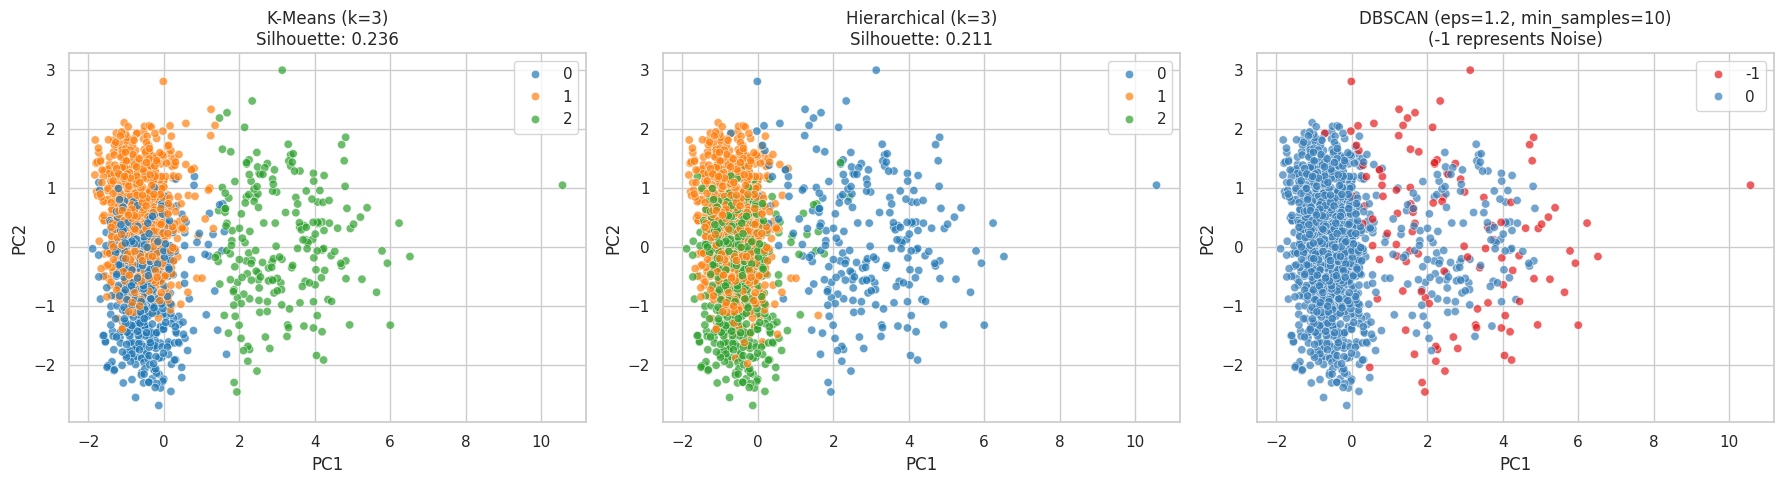

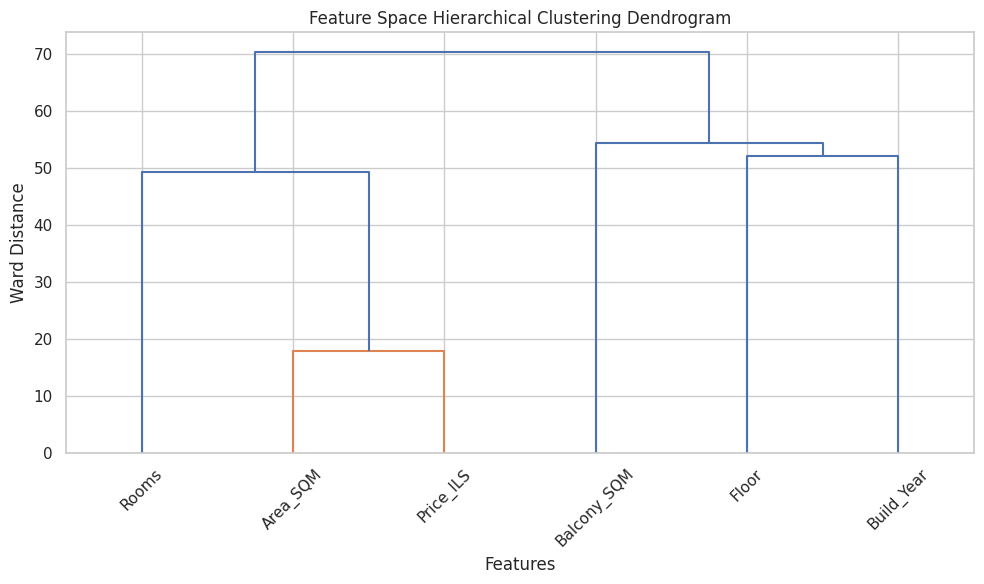

In [4]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# 1. סינון עמודות מזהות (IDs) וטעינת הפיצ'רים הרלוונטיים בלבד
drop_cols = [c for c in df.columns if 'id' in c.lower()]
X_features = df.select_dtypes(include=[np.number]).drop(columns=drop_cols, errors='ignore').dropna()

# תקנון הנתונים
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# PCA להורדת ממד לצורך ויזואליזציה (2D)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# 2. הרצת K-Means (נבחר k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 3. הרצת Hierarchical Clustering (Ward)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

# 4. הרצת DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# 5. ויזואליזציה של שלושת המודלים על גבי הטלת ה-PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# תרשים K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10', ax=axes[0], alpha=0.7)
axes[0].set_title(f'K-Means (k=3)\nSilhouette: {silhouette_score(X_scaled, kmeans_labels):.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# תרשים Hierarchical
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hier_labels, palette='tab10', ax=axes[1], alpha=0.7)
axes[1].set_title(f'Hierarchical (k=3)\nSilhouette: {silhouette_score(X_scaled, hier_labels):.3f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# תרשים DBSCAN (נקודות -1 מסומנות כרעש)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='Set1', ax=axes[2], alpha=0.7)
axes[2].set_title('DBSCAN (eps=1.2, min_samples=10)\n(-1 represents Noise)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# 6. אשכול על מרחב הפיצ'רים (Feature Space Clustering - Transpose Matrix)
feature_matrix = X_scaled.T  # שחלוף המטריצה: כל שורה מייצגת פיצ'ר

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(
    sch.linkage(feature_matrix, method='ward'),
    labels=X_features.columns.tolist(),
    leaf_rotation=45,
    leaf_font_size=11
)
plt.title('Feature Space Hierarchical Clustering Dendrogram')
plt.xlabel('Features')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.show()

# חלק 5: זיהוי אנומליות רב-ממדי (Multi-Dimensional Anomaly Detection)

## 1. Z-Score Method
* **אינטואיציה מתמטית:** מודד את המרחק של ערך מהממוצע ביחידות של סטיית תקן:
  $$Z = \frac{X - \mu}{\sigma}$$
  ברמה רב-ממדית, אנו מחשבים מדד מרחק משוקלל (או חריגה לפי ערך $Z$ מקסימלי מעבר לסף שנקבע, כגון $|Z| > 3$).
* **הנחות ומגבלות:** מניח התפלגות נורמלית (גאוסיאנית) של הנתונים. בנתוני נדל"ן בעלי זנב ימני כבד (Heavy Tails), השיטה עלולה לייצר אזעקות שווא (False Positives) עבור נכסי יוקרה לגיטימיים. כמו כן, בחינה חד-ממדית מפספסת אנומליות קשר רב-ממדיות (Multivariate Outliers).

## 2. Isolation Forest
* **אינטואיציה מתמטית:** אלגוריתם מבוסס אנסמבל עצים המנצל את העובדה שתצפיות חריגות הן "מעטות ושונות". האלגוריתם מבצע חיתוכים אקראיים במרחב הפיצ'רים. תצפיות אנומליות מבודדות במספר חיתוכים מועט (עומק עץ קצר - Average Path Length קטן), בעוד שתצפיות נורמליות דורשות עומק רב יותר לבידודן.
* **היפר-פרמטרים:** פרמטר ה-`contamination` מגדיר את שיעור האנומליות המשוער בדאטה (נקבע ל-5%).
* **יתרונות:** יעיל מאוד חישובית, עמיד לממדים גבוהים, ואינו מניח התפלגות פרמטרית מוקדמת.

## 3. Local Outlier Factor (LOF)
* **אינטואיציה מתמטית:** שיטה מבוססת צפיפות המודדת את צפיפות הדגימות בסביבת $k$-השכנים הקרובים של נקודה ביחס לצפיפות של אותם שכנים (Local Reachability Density).
* **אנומליה מקומית מול גלובלית:** ערך LOF הקרוב ל-1 מעיד על צפיפות דומה לשכנים (נקודה נורמלית), בעוד שערך הגדול משמעותית מ-1 מעיד על צפיפות נמוכה בהרבה משכניה (אנומליה מקומית). הדבר מאפשר לזהות דירה חריגה ביחס לשכונה שלה, גם אם ברמה הארצית הכללית היא נראית רגילה.
* **היפר-פרמטרים:** מספר השכנים ($k = \text{n\_neighbors}$) קובע את רדיוס הסביבה המקומית.

=== Anomaly Count by Method ===
Z-Score detected: 72 anomalies
Isolation Forest detected: 72 anomalies
LOF detected: 72 anomalies


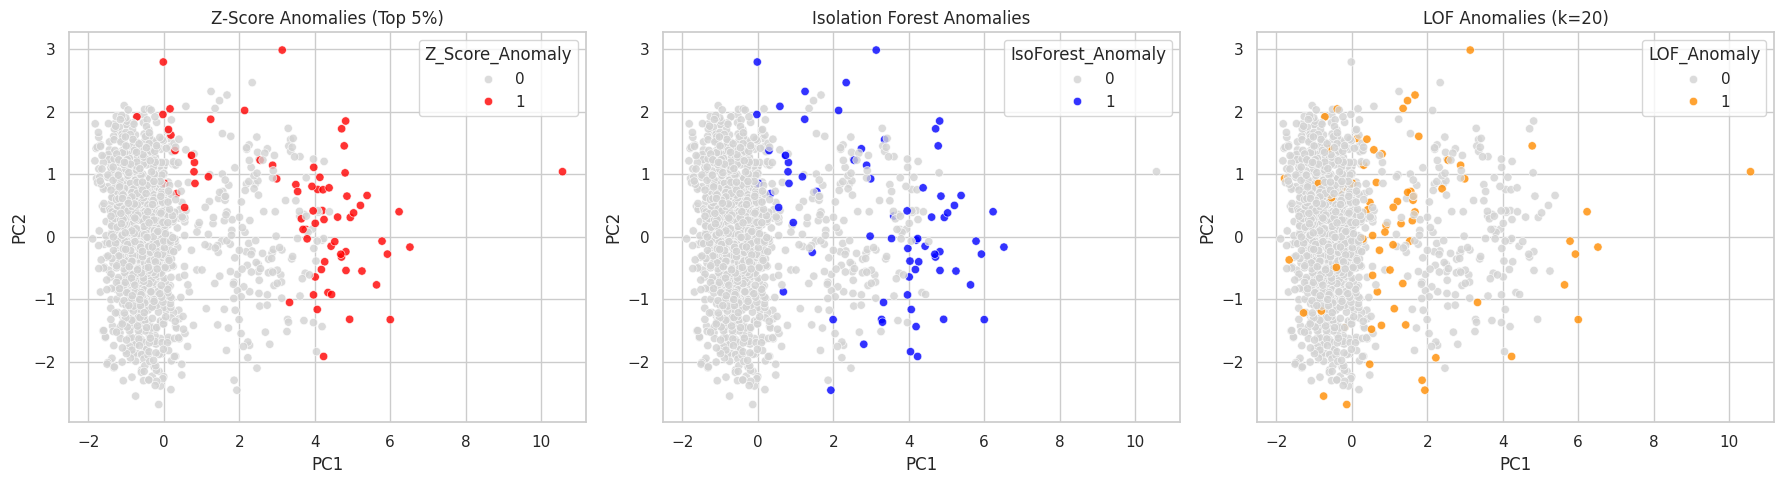

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# הגדרת שיעור זיהום משוער (Contamination rate)
CONTAMINATION = 0.05

# 1. שיטת Z-Score (חישוב מרחק Z מקסימלי לתצפית)
z_scores = np.abs(X_scaled)
max_z_per_sample = np.max(z_scores, axis=1)
# סף זיהוי עבור Z-score לפי אחוזון ה-Contamination
z_threshold = np.percentile(max_z_per_sample, 100 * (1 - CONTAMINATION))
z_anomalies = (max_z_per_sample > z_threshold).astype(int)

# 2. שיטת Isolation Forest
iso_forest = IsolationForest(contamination=CONTAMINATION, random_state=42)
iso_pred = iso_forest.fit_predict(X_scaled)
iso_anomalies = (iso_pred == -1).astype(int)
iso_scores = iso_forest.decision_function(X_scaled)

# 3. שיטת Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
lof_pred = lof.fit_predict(X_scaled)
lof_anomalies = (lof_pred == -1).astype(int)
lof_scores = -lof.negative_outlier_factor_

# שמירת התוצאות ב-DataFrame להשוואה
anomaly_df = X_features.copy()
anomaly_df['PC1'] = X_pca[:, 0]
anomaly_df['PC2'] = X_pca[:, 1]
anomaly_df['Z_Score_Anomaly'] = z_anomalies
anomaly_df['IsoForest_Anomaly'] = iso_anomalies
anomaly_df['LOF_Anomaly'] = lof_anomalies

# ספירת אנומליות שזוהו
print("=== Anomaly Count by Method ===")
print(f"Z-Score detected: {z_anomalies.sum()} anomalies")
print(f"Isolation Forest detected: {iso_anomalies.sum()} anomalies")
print(f"LOF detected: {lof_anomalies.sum()} anomalies")

# 4. ויזואליזציה של האנומליות על גבי מרחב ה-PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# תרשים Z-Score
sns.scatterplot(x='PC1', y='PC2', hue='Z_Score_Anomaly', data=anomaly_df,
                palette={0: 'lightgray', 1: 'red'}, ax=axes[0], alpha=0.8)
axes[0].set_title(f'Z-Score Anomalies (Top {int(CONTAMINATION*100)}%)')

# תרשים Isolation Forest
sns.scatterplot(x='PC1', y='PC2', hue='IsoForest_Anomaly', data=anomaly_df,
                palette={0: 'lightgray', 1: 'blue'}, ax=axes[1], alpha=0.8)
axes[1].set_title(f'Isolation Forest Anomalies')

# תרשים Local Outlier Factor
sns.scatterplot(x='PC1', y='PC2', hue='LOF_Anomaly', data=anomaly_df,
                palette={0: 'lightgray', 1: 'darkorange'}, ax=axes[2], alpha=0.8)
axes[2].set_title(f'LOF Anomalies (k=20)')

plt.tight_layout()
plt.show()

# חלק 6: השוואת שיטות זיהוי אנומליות (Comparison Section)

## 1. רמת ההסכמה וחפיפת המודלים (Agreement & Disagreements)
* **אנומליות מוסכמות (Consensus Anomalies):** תצפיות המזוהות על ידי כל שלוש השיטות הן לרוב אנומליות גלובליות קיצוניות וברורות (כגון שטח ענק, מספר חדרים חריג ומחיר קיצוני בו-זמנית).
* **אנומליות ייחודיות לשיטה (Method-Specific):**
  - **Z-Score בלבד:** נוטה לסמן נקודות בעלות ערך קיצוני בציר יחיד, גם אם שאר המשתנים מתאימים לחלוטין.
  - **LOF בלבד:** לוכד אנומליות מקומיות – נכס שהערכים שלו תקינים ברמה הארצית, אך ביחס לסביבתו המקומית המיידית (צפיפות השכנים) הוא מבודד.
  - **Isolation Forest בלבד:** מזהה שילובים רב-ממדיים נדירים (Non-linear multi-attribute combinations) שאינם קיצוניים באף ציר בודד.

## 2. השוואת תכונות ומאפיינים מתודולוגיים
* **רגישות ל-Feature Scaling:**
  - `Z-Score` ו-`LOF`: רגישים ביותר לתקנון; LOF מבוסס על מרחקים אוקלידיים שיוסטו ללא סטנדרטיזציה.
  - `Isolation Forest`: אדיש לחלוטין לסקיילינג היות שחיתוכי העצים מבוססים על יחסי סדר (Monotonic transformations).
* **רגישות לממדיות הנתונים (Dimensionality):**
  - `LOF`: סובל מ"קללת הממדיות" (Curse of Dimensionality) – בממדים גבוהים המרחקים מתכנסים והצפיפות המקומית מאבדת מובהקות.
  - `Isolation Forest`: עמיד ויציב בממדים גבוהים בזכות אקראיות בחירת הפיצ'רים.
  - `Z-Score`: מחמיר ככל שמספר הממדים גדל (הסתברות גוברת שמשתנה כלשהו יחרוג שרירותית).
* **זמן ריצה וסקלביליות (Scalability):**
  - `Z-Score`: מהיר ביותר, $O(n \cdot d)$.
  - `Isolation Forest`: מהיר וסקלבילי למאגרי ענק, $O(t \cdot \psi \log \psi)$ כאשר $\psi$ הוא גודל תת-המדגם.
  - `LOF`: איטי משמעותית עקב חישוב מטריצת מרחקים ושכנים קרובים, $O(n^2 \cdot d)$.
* **עמידות לרעש (Robustness):**
  - `Z-Score`: רגיש מאוד (הממוצע וסטיית התקן עצמם מושפעים מרעש וזנבות כבדים).
  - `Isolation Forest`: עמיד מאוד הודות למנגנון המיצוע באנסמבל.
  - `LOF`: רגיש במידה מתונה, תלוי בבחירת $k$.

## 3. ניתוח שגיאות בעולם האמיתי: False Positives מול False Negatives
* **חיובי כוזב (False Positive - התראת שווא):**
  - **משמעות:** סיווג דירת פנטהאוז לגיטימית או וילה ייחודית כעסקה חשודה/פסולה.
  - **השלכות בעולם האמיתי:** דחייה שגויה של בקשת משכנתה על ידי בנק, עיכוב אישור עסקה ברשות המיסים, או עומס בדיקות ידניות יקרות.
* **שלילי כוזב (False Negative - פספוס חריגה):**
  - **משמעות:** אי-זיהוי של הלבנת הון, דיווח מחיר פיקטיבי לצורכי מס, או עסקת עוקץ.
  - **השלכות בעולם האמיתי:** הפסדי מיסוי למדינה, חשיפת בנקים לסיכוני אשראי בלתי מכוסים ופגיעה באמינות מאגר הנתונים הציבורי.

=== Anomaly Detection Summary ===


,Method,Detected Count
0,Z-Score,72
1,Isolation Forest,72
2,LOF,72



=== Observations by Agreement Count ===
Flagged by 0 method(s): 1275 observations
Flagged by 1 method(s): 94 observations
Flagged by 2 method(s): 40 observations
Flagged by 3 method(s): 14 observations


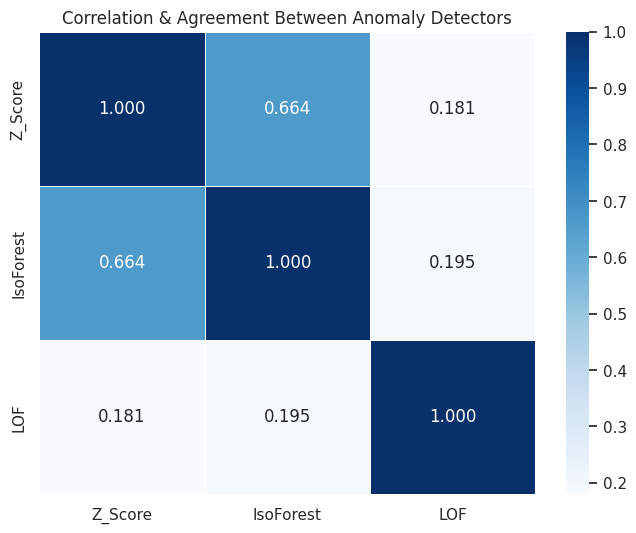

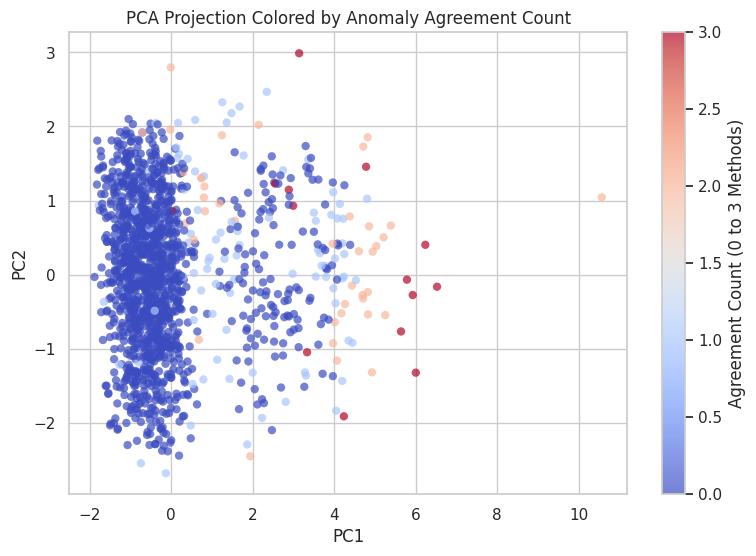


Found 14 Consensus Anomalies (Flagged by ALL 3 methods):


,Transaction_ID,City,Property_Type,Rooms,Floor,Area_SQM,Price_ILS,Build_Year,Transaction_Date,Has_Elevator,Has_Parking,Balcony_SQM
366,10367,Petah Tikva,Apartment,5.0,1,113.5,2852000.0,2023.0,2026-01-02,True,True,7.5
470,10471,Tel Aviv,Apartment,4.5,1,123.2,6272000.0,1969.0,2026-05-01,False,True,0.0
539,10540,Tel Aviv,Apartment,4.0,5,118.6,4990000.0,NaN,2025-02-22,True,False,45.9
567,10568,Ramat Gan,Apartment,4.0,6,55.3,2220000.0,2003.0,2025-09-05,True,True,NaN
606,10607,Tel Aviv,Apartment,4.5,6,99.9,4048000.0,1984.0,2025-08-21,True,True,0.0


In [6]:
# 1. חישוב טבלת הסכמה בין המודלים
anomaly_comparison = pd.DataFrame({
    'Method': ['Z-Score', 'Isolation Forest', 'LOF'],
    'Detected Count': [z_anomalies.sum(), iso_anomalies.sum(), lof_anomalies.sum()]
})
print("=== Anomaly Detection Summary ===")
display(anomaly_comparison)

# 2. חישוב כמות התצפיות לפי רמת הסכמה
anomaly_matrix = pd.DataFrame({
    'Z_Score': z_anomalies,
    'IsoForest': iso_anomalies,
    'LOF': lof_anomalies
})

# סך המודלים שסימנו כל דגימה
anomaly_matrix['Agreement_Count'] = anomaly_matrix.sum(axis=1)
agreement_counts = anomaly_matrix['Agreement_Count'].value_counts().sort_index()

print("\n=== Observations by Agreement Count ===")
for count, n_obs in agreement_counts.items():
    print(f"Flagged by {count} method(s): {n_obs} observations")

# 3. מטריצת קורלציה / חפיפה בין המודלים (Jaccard / Correlation)
corr_matrix = anomaly_matrix[['Z_Score', 'IsoForest', 'LOF']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".3f", linewidths=0.5)
plt.title('Correlation & Agreement Between Anomaly Detectors')
plt.show()

# 4. ויזואליזציה של רמת ההסכמה על גבי מרחב ה-PCA
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    anomaly_df['PC1'],
    anomaly_df['PC2'],
    c=anomaly_matrix['Agreement_Count'],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='none'
)
plt.colorbar(scatter, label='Agreement Count (0 to 3 Methods)')
plt.title('PCA Projection Colored by Anomaly Agreement Count')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# 5. הצגת דוגמאות לתצפיות מוסכמות (Consensus Outliers)
consensus_idx = anomaly_matrix[anomaly_matrix['Agreement_Count'] == 3].index
print(f"\nFound {len(consensus_idx)} Consensus Anomalies (Flagged by ALL 3 methods):")
display(df.loc[consensus_idx].head(5))

# חלק 7: ניתוח ביקורתי, רפלקציה והיבטים אתיים (Critical Analysis & Reflection)

## 1. הבעייתיות המובנית בזיהוי אנומליות (Ill-Defined Problem)
זיהוי אנומליות הוא אתגר מורכב ביסודו (Ill-defined problem) כיוון שבהיעדר תיוג מנחה (Ground Truth), הגדרת ה"חריג" תלויה לחלוטין בהנחות המודל, במדד המרחק הנבחר וברזולוציית הניתוח. אין גבול מתמטי מוחלט בין התנהגות נדירה אך לגיטימית לבין שגיאת מדידה או פעילות עוינת.

## 2. קללת הממדיות ומדדי מרחק (Curse of Dimensionality)
* **אובדן משמעות המרחק האוקלידי:** ככל שמספר הממדים גדל, המרחק בין כל שתי נקודות במרחב הולך ומתכנס לערך ממוצע כמעט אחיד ($d_{\max} - d_{\min} \to 0$). מרחב הנתונים הופך לדליל בצורה קיצונית (Empty space phenomenon).
* **השפעה על מודלים:** אלגוריתמים המבוססים על מרחק וצפיפות מקומית (כגון LOF ו-KNN) מתקשים להבחין בין סביבה "צפופה" ל"דלילה" בממדים גבוהים, ועלולים לסווג נקודות תקינות כאנומליות באופן שגוי.

## 3. הבחנה בין רעש, שגיאת מדידה ואנומליה לגיטימית (Noise vs. Genuine Anomaly)
* **רעש / שגיאת הזנה (Artifacts):** דיווח על דירת 3 חדרים בשטח 10 מ"ר או מחיר מכירה של 0 ש"ח. אלו שגיאות טכניות שיש לסנן.
* **אנומליה לגיטימית (Rare but Valid):** נכס יוקרה יוצא דופן (כגון פנטהאוז רחב ידיים עם בריכה על הגג במרכז תל אביב). הנכס מתרחק משמעותית ממרכז ההתפלגות, אך מייצג עסקה אמיתית לחלוטין.
* **סיכון סינון אוטומטי:** הסרה עיוורת של אנומליות כאלו תמחק את הדוגמאות בעלות הערך הכלכלי הגבוה ביותר ותטה את מודלי החיזוי כלפי מטה.

## 4. סיכוני ההנחה הגאוסיאנית (Gaussianity Assumption)
הנחת נורמליות (כמו ב-Z-Score) מניחה זנבות דועכים אקספוננציאלית. נתוני נדל"ן מתאפיינים בזנבות כבדים (Heavy Tails / Power Law). כתוצאה מכך:
1. **False Positives:** נכסים יקרים או גדולים מקבלים Z-score קיצוני ומסומנים כאנומליה אף שהם חלק אינטגרלי מהשוק.
2. **False Negatives:** אנומליות מורכבות המתבטאות בקשרים לא-לינאריים בין פיצ'רים יפוספסו לחלוטין.

## 5. מגבלות הוויזואליזציה בהורדת ממד (PCA Projection Pitfalls)
הטלת נתונים ממרחב רב-ממדי למרחב דו-ממדי באמצעות PCA לוכדת רק את צירי השונות המקסימלית הגלובלית:
* שתי נקודות שנראות צמודות בגרף ה-2D עשויות להיות רחוקות מאוד בממדים שאינם מוצגים (Projection Artifact).
* נקודה הנראית מבודדת במרחב ה-PCA עשויה להיראות כך רק בשל גודל המשתנה ולא בגלל חריגות מקומית אמיתית.

---

## 6. היבטים אתיים והשלכות בעולם האמיתי (Ethical Considerations)

* **השלכות של התראות שווא (False Alarms):**
  - "עייפות התראות" (Alert Fatigue): ריבוי אזעקות שווא גורם לאנליסטים ולרגולטורים להתעלם מהמערכת, מה שמביא לפספוס חריגות אמיתיות.
  - פגיעה באזרחים: חסימה אוטומטית של עסקאות כשרות עלולה לפגוע בזכויות קניין ולגרום לעיכובים בירוקרטיים קשים.

* **שימושים במעקב ואכיפה (Surveillance):**
  - זיהוי התנהגות "חריגה" במרחב הציבורי עלול לייצר פגיעה בפרטיות ולמשטר אוכלוסיות ללא הצדקה.

* **עולם הרפואה (Medical Diagnosis):**
  - **False Negative (פספוס גידול חריג):** עלול להוביל לחוסר טיפול ולסכנת חיים ממשית.
  - **False Positive (תיוג שגוי של רקמה בריאה כחריגה):** מוביל לטיפולים פולשניים מיותרים, חרדה קשה והוצאות רפואיות כבדות.

* **אבטחת מידע וסייבר (Cybersecurity):**
  - פספוס חדירה (False Negative) עלול להשבית ארגון שלם ולגרום לדליפת מידע קריטי, בעוד שתיוג שגוי של עובד לגיטימי (False Positive) יוצר הפרעה לפעילות העסקית.

* **הוגנות, הטיה ואפליה (Fairness & Bias):**
  - מערכות לזיהוי חריגים עלולות לתייג התנהגויות של קבוצות מיעוט או אזורים סוציו-אקונומיים ייחודיים כ"אנומליה" רק משום שהן שונות מהנורמה הסטטיסטית השלטת, ובכך להנציח אפליה מבנית (למשל במתן משכנתאות או תמחור ביטוח).

# חלק 8: דשבורד ויזואליזציה אינטראקטיבי (Optional Bonus +5%)

בחלק זה יצרנו דשבורד אינטראקטיבי מבוסס Plotly המאפשר:
1. **חקר אינטראקטיבי של מרחב ה-PCA:** ריחוף (Hover) מעל נקודות כדי לראות את מאפייני הדירה הספציפית (מחיר, שטח, חדרים).
2. **סינון והשוואת אנומליות:** הדגשה צבעונית של רמת ההסכמה בין שלושת המודלים (0 עד 3 שיטות).
3. **מטריצת פיזור (Pairplot / Scatter Matrix) ומפת חום אינטראקטיבית.**

In [7]:
import plotly.express as px
import plotly.graph_objects as go

# 1. הכנת נתונים מאוחדים לדשבורד
dash_df = X_features.copy()
dash_df['PC1'] = X_pca[:, 0].round(2)
dash_df['PC2'] = X_pca[:, 1].round(2)
dash_df['KMeans_Cluster'] = kmeans_labels.astype(str)
dash_df['Agreement_Count'] = anomaly_matrix['Agreement_Count'].astype(str)
dash_df['Anomaly_Status'] = anomaly_matrix['Agreement_Count'].apply(
    lambda x: 'Normal (0)' if x == 0 else f'Flagged by {x} method(s)'
)

# 2. תרשים PCA אינטראקטיבי עם פרטי דירה בריחוף (Hover)
fig_pca = px.scatter(
    dash_df,
    x='PC1',
    y='PC2',
    color='Anomaly_Status',
    hover_data=X_features.columns.tolist(),
    title='Interactive PCA Space & Anomaly Exploration',
    color_discrete_map={
        'Normal (0)': 'lightgray',
        'Flagged by 1 method(s)': '#6baed6',
        'Flagged by 2 method(s)': '#fd8d3c',
        'Flagged by 3 method(s)': '#de2d26'
    },
    template='plotly_white',
    height=600
)
fig_pca.show()

# 3. מפת חום אינטראקטיבית של קורלציות (Interactive Heatmap)
corr_interactive = X_features.corr().round(2)
fig_corr = px.imshow(
    corr_interactive,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title='Interactive Correlation Heatmap'
)
fig_corr.show()

# 4. מטריצת פיזור אינטראקטיבית לפיצ'רים מובילים (Scatter Matrix / Pairplot)
key_cols = X_features.columns[:4].tolist()  # 4 הפיצ'רים הראשונים
fig_matrix = px.scatter_matrix(
    dash_df,
    dimensions=key_cols,
    color='KMeans_Cluster',
    title='Interactive Pairplot / Scatter Matrix (Colored by Cluster)',
    height=750
)
fig_matrix.show()